In [362]:
import pandas as pd

df = pd.read_excel(r"../data/raw/Coffee Shop Sales.xlsx")

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [363]:
df['revenue'] = df['transaction_qty'] * df['unit_price']

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [364]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [365]:
df["hour"] = df["transaction_time"].apply(lambda x: x.hour)

In [366]:
df["day_of_week"] = df["transaction_date"].dt.day_name()

In [367]:
df["day"] = df["transaction_date"].dt.day

In [368]:
df["phase"] = df["transaction_time"].apply(
    lambda x: "Morning" if x.hour < 12 else
              "Afternoon" if x.hour < 16 else
              "Evening"
)

In [369]:
import matplotlib.pyplot as plt

In [370]:
def plot_chart(data, kind="", title="", xlabel="", ylabel="", figsize=(8,5)):
    plt.figure(figsize=figsize)
    
    if kind == "line":
        data.plot(kind="line", marker="o")
    else:
        data.plot(kind=kind)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [371]:
df_grouped_hour = df.groupby("hour").agg({
    "transaction_id": "count",
    "revenue": "sum",
    "transaction_qty": "sum"
})

<Figure size 800x500 with 0 Axes>

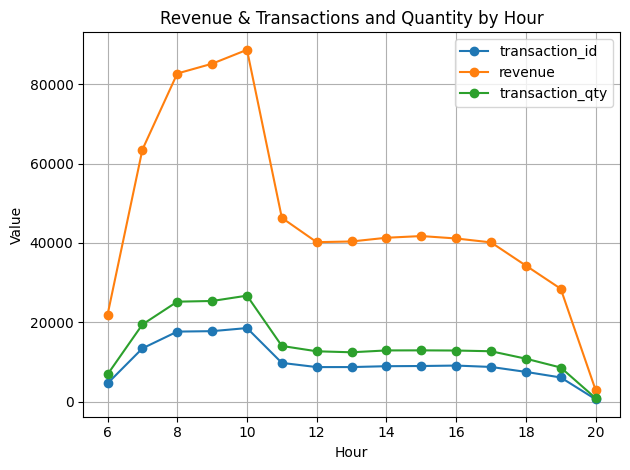

In [372]:
plot_chart(df_grouped_hour,"line", "Revenue & Transactions and Quantity by Hour", "Hour", "Value")

## Insight: by Hour

- Peak hour: 6:00–10:00
- Low hour: 11:00–20:00

### Observation
Tranaction, Revenue and Quantity สูงช่วงเช้าจนถึง 10.00

### Hypothesis
ลูกค้าหลักเป็นพนักงานออฟฟิศที่ซื้อช่วงก่อนเริ่มงาน

In [373]:
df_grouped_dayweek = df.groupby("day_of_week").agg({
    "revenue": "sum",
    "transaction_id": "count",
    "transaction_qty": "sum"
})

<Figure size 800x500 with 0 Axes>

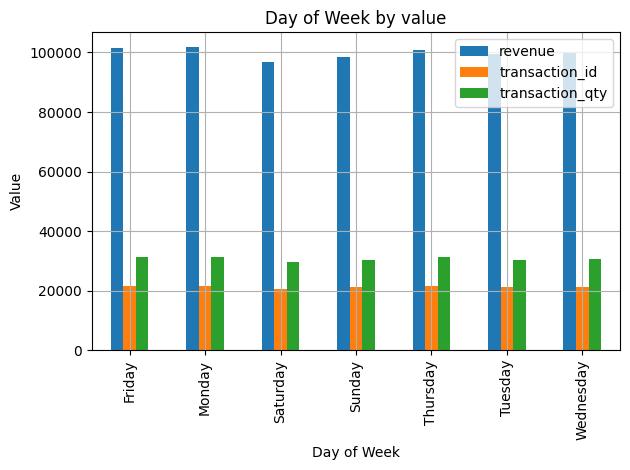

In [374]:
plot_chart(df_grouped_dayweek, "bar", "Day of Week by value", xlabel="Day of Week", ylabel="Value")

## Observation

แต่ละวันมี Transaction, Quantity and Revenue ไม่แตกต่างกัน

### Hypothesis
วันในสัปดาห์มีผลต่อ Revenue, Transaction and Revenue

In [375]:
df_grouped_day = df.groupby("day").agg({
    "revenue": "sum",
    "transaction_id": "count",
    "transaction_qty": "sum"
})

<Figure size 800x500 with 0 Axes>

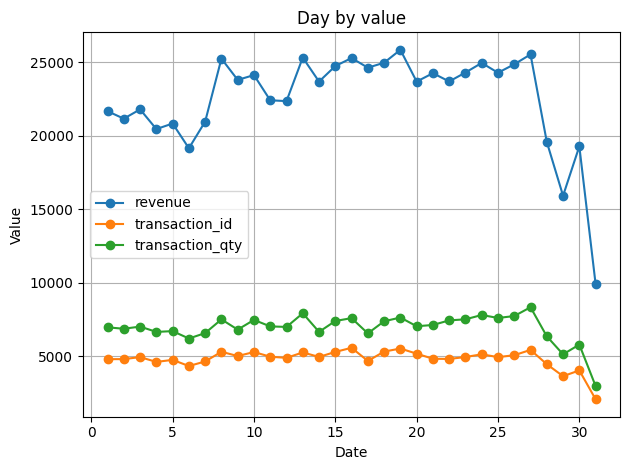

In [376]:
plot_chart(df_grouped_day, "line", "Day by value", xlabel="Date", ylabel="Value")

## Insight: by Day

- Peak Day: 8-27
- Low hour: 28-7

### Observation
ช่วงสัปดาห์กลางเดือนมี Transaction, Quantity and Revenue ที่สูงกว่าช่วงต้นเดือนและสิ้นเดือน

### Hypothesis
Transaction, Quantity and Revenue ในแต่ละวันแตกต่างกันหรือไม่

In [377]:
df_grouped_location = df.groupby("store_location").agg({
    "revenue": "sum",
    "transaction_id": "count",
    "transaction_qty": "sum"
})

<Figure size 800x500 with 0 Axes>

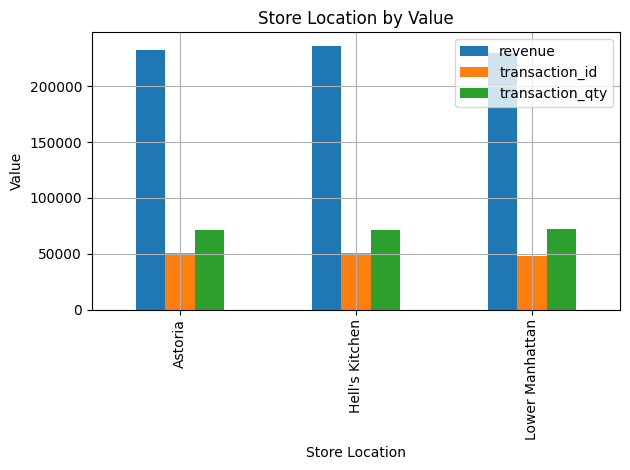

In [378]:
plot_chart(df_grouped_location, "bar", "Store Location by Value", xlabel="Store Location", ylabel="Value")

## Observation

Location มี Transaction Quantity and Revenue ที่ไม่แตกต่างกัน

### Hypothesis
Location ผลต่อ Transaction Quantity and Revenue

In [379]:
df_grouped_category = df.groupby("product_category").agg({
    "revenue": "sum",
    "transaction_id": "count",
    "transaction_qty": "sum"
})

<Figure size 800x500 with 0 Axes>

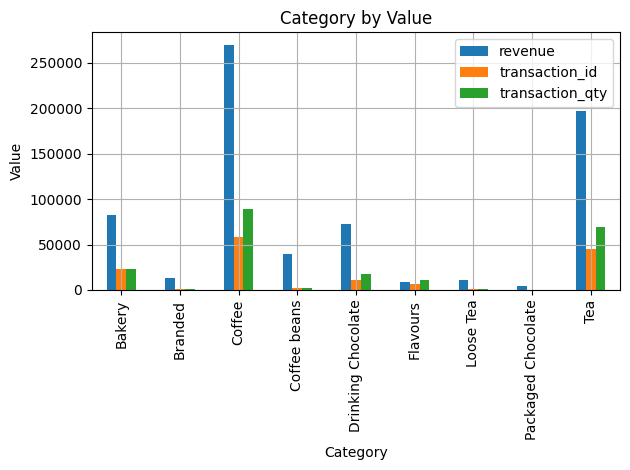

In [380]:
plot_chart(df_grouped_category, "bar", "Category by Value", xlabel="Category", ylabel="Value")

### Observation
Transaction, Quantity and Revenue แต่ละ Category แตกต่างกัน

### Hypothesis
Transaction, Quantity and Revenue แต่ละ Category แตกต่างกันหรือไม่

In [381]:
df_grouped_phase = df.groupby("phase").agg({
    "revenue": "sum",
    "transaction_id": "count",
    "transaction_qty": "sum"
})

<Figure size 800x500 with 0 Axes>

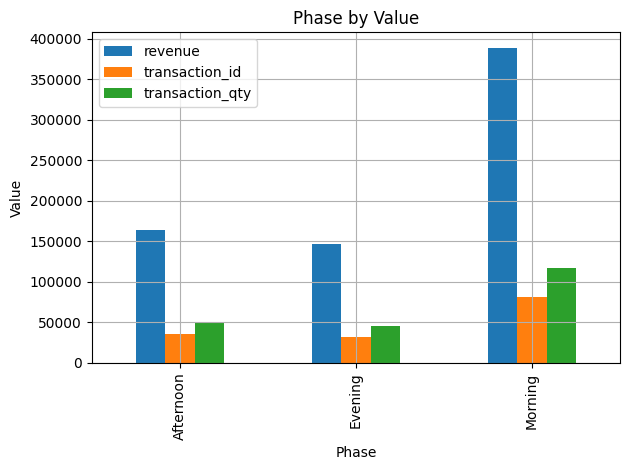

In [382]:
plot_chart(df_grouped_phase, "bar", "Phase by Value", xlabel="Phase", ylabel="Value")

### Observation
Transaction, Quantity and Revenue แต่ละ Phase แตกต่างกัน

### Hypothesis
Transaction, Quantity and Revenue แต่ละ Phase แตกต่างกันหรือไม่

🔹 1: Hour of Day Effect  
  
H0: Transaction volume is the same across all Hour of Day  
  
H1: Transaction volume differs across Hour of Day

ลืม test สมมติฐาน

In [383]:
hourly_transaction_daily = df.groupby(["transaction_date","hour"])["transaction_id"].count().reset_index(name="transaction_count")

In [384]:
hourly_transaction_avg = hourly_transaction_daily.groupby("hour")["transaction_count"].mean().reset_index()

In [385]:
from sklearn.cluster import KMeans

X = hourly_transaction_avg[["transaction_count"]]

kmeans = KMeans(n_clusters=3, random_state=42)
hourly_transaction_avg["cluster"] = kmeans.fit_predict(X)

In [386]:
import matplotlib.pyplot as plt

In [387]:
hourly_transaction_avg.sort_values("transaction_count")
print(hourly_transaction_avg)

    hour  transaction_count  cluster
0      6          44.173077        0
1      7          74.187845        2
2      8          97.535912        1
3      9          98.143646        1
4     10         102.458564        1
5     11          53.955801        0
6     12          48.110497        0
7     13          48.143646        0
8     14          49.353591        0
9     15          49.607735        0
10    16          50.237569        0
11    17          48.314917        0
12    18          41.425414        0
13    19          33.657459        0
14    20          10.963636        0


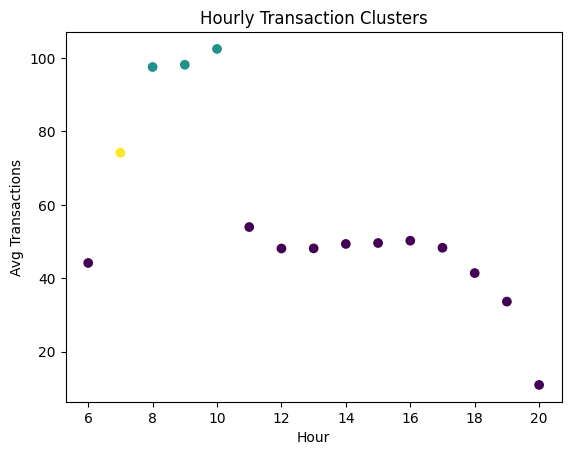

In [388]:
plt.scatter(hourly_transaction_avg["hour"], hourly_transaction_avg["transaction_count"], 
            c=hourly_transaction_avg["cluster"])

plt.title("Hourly Transaction Clusters")
plt.xlabel("Hour")
plt.ylabel("Avg Transactions")
plt.show()

🔹 H1: Hour of Day Effect  
  
H0: Qty is the same across all Hour of Day  
  
H1: Qty volume differs across Hour of Day

In [389]:
hourly_qty_daily = df.groupby(["transaction_date", "hour"])["transaction_qty"].sum().reset_index()

In [390]:
hourly_qty_avg = hourly_qty_daily.groupby("hour")["transaction_qty"].mean().reset_index(name="avg_qty")

In [391]:
x = hourly_qty_avg["avg_qty"]

kmeans = KMeans(n_clusters=3, random_state=42)
hourly_qty_avg["cluster"] = kmeans.fit_predict(X)

In [392]:
print(hourly_qty_avg)

    hour     avg_qty  cluster
0      6   66.009615        0
1      7  107.453039        2
2      8  139.209945        1
3      9  140.165746        1
4     10  147.585635        1
5     11   77.541436        0
6     12   70.110497        0
7     13   68.723757        0
8     14   71.309392        0
9     15   71.397790        0
10    16   71.165746        0
11    17   70.165746        0
12    18   59.812155        0
13    19   47.486188        0
14    20   16.000000        0


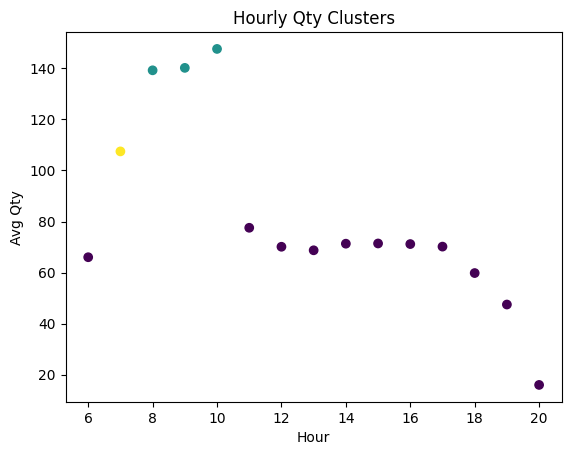

In [393]:
plt.scatter(hourly_qty_avg["hour"], hourly_qty_avg["avg_qty"],
            c=hourly_qty_avg["cluster"])

plt.title("Hourly Qty Clusters")
plt.xlabel("Hour")
plt.ylabel("Avg Qty")
plt.show()

🔹 H1: Hour of Day Effect  
  
H0: Revenue is the same across all Hour of Day  
  
H1: Revenue volume differs across Hour of Day

In [401]:
hourly_revenue_daily = df.groupby(["transaction_date", "hour"])["revenue"].sum().reset_index()

In [402]:
hourly_revenue_avg = hourly_revenue_daily.groupby("hour")["revenue"].mean().reset_index(name="avg_revenue")

In [403]:
X = hourly_revenue_avg[["avg_revenue"]]

kmeans = KMeans(n_clusters=3, random_state=42)
hourly_revenue_avg["cluster"] = kmeans.fit_predict(X)

In [404]:
hourly_revenue_avg.sort_values("avg_revenue")
print(hourly_revenue_avg)

    hour  avg_revenue  cluster
0      6   210.579519        0
1      7   350.974972        2
2      8   456.905359        1
3      9   470.549890        1
4     10   489.908232        1
5     11   255.906851        0
6     12   222.059613        0
7     13   223.024586        0
8     14   228.202983        0
9     15   230.569613        0
10    16   227.197514        0
11    17   221.736519        0
12    18   189.426519        0
13    19   157.163978        0
14    20    53.375273        0


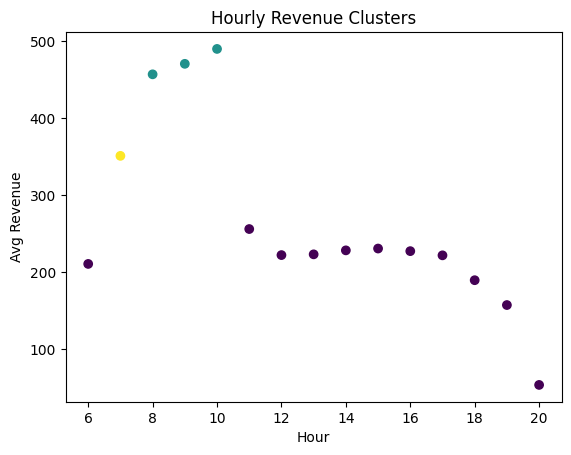

In [405]:
plt.scatter(hourly_revenue_avg["hour"], hourly_revenue_avg["avg_revenue"],
            c=hourly_revenue_avg["cluster"])

plt.title("Hourly Revenue Clusters")
plt.xlabel("Hour")
plt.ylabel("Avg Revenue")
plt.show()

🔹 H2: Day of Week Effect  
  
H0: Transaction is the same across all Hour of Day  
  
H1: Transaction volume differs across Hour of Day

In [415]:
dayweek_tracsaction = df.groupby(["transaction_date", "day_of_week"])["transaction_id"].count().reset_index(name="avg_transaction")

In [416]:
dayweek_tracsaction_avg = dayweek_tracsaction.groupby("day_of_week")["avg_transaction"].mean().reset_index()

In [421]:
X = dayweek_tracsaction_avg[["avg_transaction"]]

kmeans = KMeans(n_clusters=3, random_state=42)
dayweek_tracsaction_avg["cluster"] = kmeans.fit_predict(X)

In [422]:
print(dayweek_tracsaction_avg)

  day_of_week  avg_transaction  cluster
0      Friday       834.653846        1
1      Monday       832.423077        1
2    Saturday       820.400000        0
3      Sunday       811.384615        2
4    Thursday       832.846154        1
5     Tuesday       815.461538        2
6   Wednesday       819.615385        0


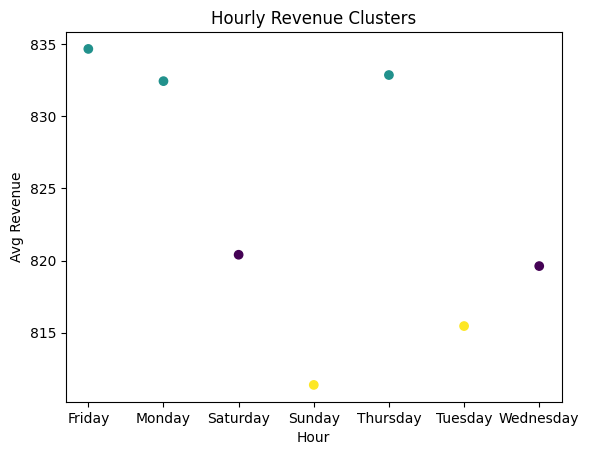

In [423]:
plt.scatter(dayweek_tracsaction_avg["day_of_week"], dayweek_tracsaction_avg["avg_transaction"],
            c=dayweek_tracsaction_avg["cluster"])

plt.title("Hourly Revenue Clusters")
plt.xlabel("Hour")
plt.ylabel("Avg Revenue")
plt.show()